In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve,
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
gt_ip = pd.read_csv("PyCharmMiscProject/gt_ip_processed.csv")

In [3]:
gt_ip.head()

,admitdate,dischargedate,deid_personid,planpayer,patient_city,patient_state,patient_zip,pcpnpi,pcpname,ehn_vs_non,employed_vs_independent,ehn_practice,lhn,entity,cost,paiddate,placeofservice,placeofservicedescription,primary_cpt,cptdescription,primary_icd,icddescription,servicing_prov,servicing_specialty,rptgrouper,servicefacility,servicefacilitynpi,readmission,readmission60,readmission90,followup7dayind,followup30daytcoc,dischargedisposition,los_days
0,2024-12-22,2024-12-29,56a053a2c5f5a16146246c8cd206b15f,Emory Anthem Commercial,BUFORD,GA,30519,UNKNOWN,UNKNOWN,Unknown,Unknown,Unknown,Unknown,Unknown,304.81,2025-01-09,55,Residential Substance Abuse Treatment Facility,86480,TB CELL MEDIATED ANTIGN RESPNSE GAMMA INTERFERON,F13.20,"Sedative, hypnotic or anxiolytic dependence, u...",1033749940,Clinical Medical Laboratory,IP BEHAVIORAL HEALTH,"SUNRISE DETOX ALPHARETTA, LLC",1427440999,1,1,1,1,218.36,HOME,7
1,2024-11-30,2024-12-13,282bfaa0946165ec48dd67c64bd43a67,Emory Anthem Commercial,UNION CITY,GA,30291,UNKNOWN,UNKNOWN,Unknown,Unknown,Unknown,Unknown,Unknown,"217,605.94",2025-01-30,21,Inpatient Hospital,88350,IMMUNOFLUORESCENCE PR SPEC EA ADD SINGL ANTB STN,C83.38,"Diffuse large B-cell lymphoma, lymph nodes of ...",1699084145,Pathology,IP SURGICAL (ADULT),"PAULDING MEDICAL CENTER, INC.",1457329435,0,0,0,0,"862,755.42",HOME,13
2,2024-12-04,2024-12-16,72991e18eaf8a5cf2ccad525370c647f,Emory MSSP,LILBURN,GA,30047,1194091025,"GROSE, LEE",EHN,EHN Employed,Emory at Snellville - Oak Road,EDH,ESA,"9,172.07",2025-01-17,31,Skilled Nursing Facility,99306,INITIAL NURSING FACILITY CARE HI MDM 50 MINUTES,G93.41,Metabolic encephalopathy,1104355908,Nurse Practitioner,IP SNF,"ENGLAND ASSOCIATES, LP",1144530148,0,0,0,1,"3,814.60",HOME,12
3,2024-11-30,2024-12-04,72991e18eaf8a5cf2ccad525370c647f,Emory MSSP,LILBURN,GA,30047,1194091025,"GROSE, LEE",EHN,EHN Employed,Emory at Snellville - Oak Road,EDH,ESA,"11,803.04",2024-12-13,21,Inpatient Hospital,99239,HOSPITAL IP/OBS DISCHARGE DAY MGMT > 30 MIN,U07.1,COVID-19,1245736172,Internal Medicine,IP MEDICAL (ADULT),"EASTSIDE MEDICAL CENTER, LLC",1467406132,0,0,0,0,"13,180.36",IP SNF,4
4,2024-05-13,2024-05-16,503d9c68c71212bda9697f48ee3a5580,Emory Anthem Commercial,VILLA RICA,GA,30180,UNKNOWN,UNKNOWN,Unknown,Unknown,Unknown,Unknown,Unknown,"25,410.13",2024-06-06,21,Inpatient Hospital,59400,OB CARE ANTEPARTUM VAG DLVR & POSTPARTUM,O99.824,Streptococcus B carrier state complicating chi...,1023301660,Obstetrics & Gynecology,IP SNF,"TANNER MEDICAL CENTER, INC",1801883780,0,0,0,1,"8,141.20",HOME,3


# Modeling: High-cost patient identification + Readmission 

## Targets
1) **High-cost (patient-level):** top 10% of patients by total cost (p90).  
   Use-case: identify patients to prioritize for care management.

2) **Readmission (patient-level):** whether a patient experienced any 30-day readmission within the observation window.  
   Use-case: flag patients likely to need post-discharge support.

In [9]:
patient_summary = (
    gt_ip.groupby("deid_personid", as_index=False)
    .agg(
        n_visits=("deid_personid", "size"),
        total_cost=("cost", "sum"),
        total_los_days=("los_days", "sum"),
        avg_los_days=("los_days", "mean"),
        n_readmit_30=("readmission", "sum"),
        n_readmit_60=("readmission60", "sum"),
        n_readmit_90=("readmission90", "sum"),
    )
)

patient_summary["avg_cost_per_visit"] = (patient_summary["total_cost"] / patient_summary["n_visits"])

# costliest diagnosis per patient (by accumulated cost)
costliest_dx_per_patient = (
    gt_ip.groupby(["deid_personid", "icddescription"], as_index=False)
    .agg(total_dx_cost=("cost", "sum"))
    .sort_values(["deid_personid", "total_dx_cost"], ascending=[True, False])
    .drop_duplicates(subset="deid_personid")
    .rename(columns={"icddescription": "costliest_dx"})
    [["deid_personid", "costliest_dx"]]
)

# dominant specialty per patient (most frequent encounters)
dominant_specialty = (
    gt_ip.groupby(["deid_personid", "servicing_specialty"])
    .size()
    .reset_index(name="n_events")
    .sort_values(["deid_personid", "n_events"], ascending=[True, False])
    .drop_duplicates(subset="deid_personid")
    .rename(columns={"servicing_specialty": "dominant_specialty"})
    [["deid_personid", "dominant_specialty"]]
)

# patient-level df
patient_model_df = (
    patient_summary
    .merge(costliest_dx_per_patient, on="deid_personid", how="left")
    .merge(dominant_specialty, on="deid_personid", how="left")
    #.merge(dx_diversity,             on="deid_personid", how="left")
    #.merge(spec_diversity,           on="deid_personid", how="left")
)


# labels
for pct, col in [(0.90, "high_cost_p90"), (0.95, "high_cost_p95")]:
    threshold = patient_model_df["total_cost"].quantile(pct)
    patient_model_df[col] = (patient_model_df["total_cost"] >= threshold).astype(int)

patient_model_df["any_readmit_30"] = (patient_model_df["n_readmit_30"] > 0).astype(int)

patient_model_df.head()


,deid_personid,n_visits,total_cost,total_los_days,avg_los_days,n_readmit_30,n_readmit_60,n_readmit_90,avg_cost_per_visit,costliest_dx,dominant_specialty,high_cost_p90,high_cost_p95,any_readmit_30
0,0001f1a308be5f84297fc5986537253a,1,"23,034.29",5,5.00,0,0,0,"23,034.29","Atrioventricular block, complete",Clinical Cardiac Electrophysiology,0,0,0
1,0005d1a76d48de5ae0fbe0b7e3d52648,2,"36,842.95",25,12.50,0,0,0,"18,421.47",Nondisplaced intertrochanteric fracture of rig...,General Practice,0,0,0
2,0006d561ad6a6112d1058426fcac7c80,2,"23,268.30",11,5.50,1,1,1,"11,634.15",Heart transplant rejection,Infectious Disease,0,0,1
3,0008906edd4288519c31f8a137a1de28,1,"46,015.70",4,4.00,0,0,0,"46,015.70",Traumatic subdural hemorrhage with loss of con...,Emergency Medicine,0,0,0
4,0010ec428c1ca377ba6a2cca0243d420,1,"15,290.31",2,2.00,0,0,0,"15,290.31",Unspecified convulsions,Radiology,0,0,0


## High-Cost Class Distribution and Baseline Performance

In [5]:
patient_model_df[["high_cost_p90", "high_cost_p95", "any_readmit_30"]].mean()

high_cost_p90    0.10
high_cost_p95    0.05
any_readmit_30   0.07
dtype: float64

In [6]:
#Data Split and Baseline Model

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve
)
import matplotlib.pyplot as plt

y = patient_model_df["high_cost_p90"].copy()

X = patient_model_df[
    [
        "n_visits",
        "avg_cost_per_visit",
        "total_los_days",
        "avg_los_days",
        "costliest_dx",
        "dominant_specialty",
    ]
].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

base_rate = y_test.mean()
print("Test base rate (high_cost_p90):", base_rate)

# Predict all zeros
y_pred_all0 = np.zeros_like(y_test)
print("\nBaseline (all-0) report:")
print(classification_report(y_test, y_pred_all0, zero_division=0))

Test base rate (high_cost_p90): 0.10002942041776994

Baseline (all-0) report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      3059
           1       0.00      0.00      0.00       340

    accuracy                           0.90      3399
   macro avg       0.45      0.50      0.47      3399
weighted avg       0.81      0.90      0.85      3399



## Logistic Regression Model – High-Cost Patient Identification

In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

categorical_cols = ["costliest_dx", "dominant_specialty"]
numeric_cols = ["n_visits", "avg_cost_per_visit", "total_los_days", "avg_los_days"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

lr_model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000))
])

lr_model.fit(X_train, y_train)

lr_probs = lr_model.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, lr_probs)
pr_auc = average_precision_score(y_test, lr_probs)

print({"log_reg_roc_auc": roc, "log_reg_pr_auc": pr_auc})

{'log_reg_roc_auc': 0.9190017883583641, 'log_reg_pr_auc': 0.7915167363074195}


**Note:** Consider high correlation avg_cost_per_visit, n_visits and total_cost.

Given that the high-cost label is derived from total patient-level cost, and the model includes utilization intensity features (e.g., number of visits and average cost per visit), strong performance is expected. These features act as proxies for overall resource consumption.


------------------------------------------------------------
Logistic Regression @ threshold=0.2
              precision    recall  f1-score   support

           0       0.97      0.94      0.96      3059
           1       0.61      0.78      0.68       340

    accuracy                           0.93      3399
   macro avg       0.79      0.86      0.82      3399
weighted avg       0.94      0.93      0.93      3399



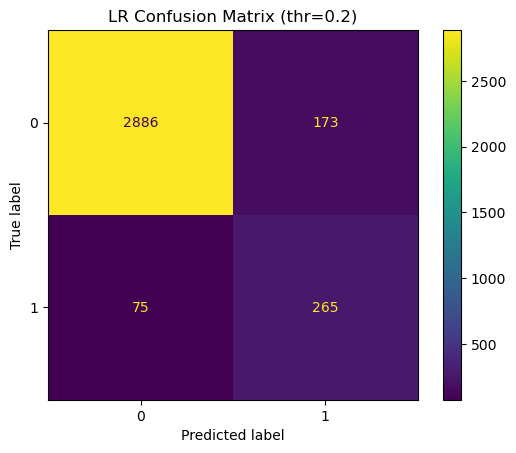


------------------------------------------------------------
Logistic Regression @ threshold=0.3
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3059
           1       0.70      0.72      0.71       340

    accuracy                           0.94      3399
   macro avg       0.83      0.84      0.84      3399
weighted avg       0.94      0.94      0.94      3399



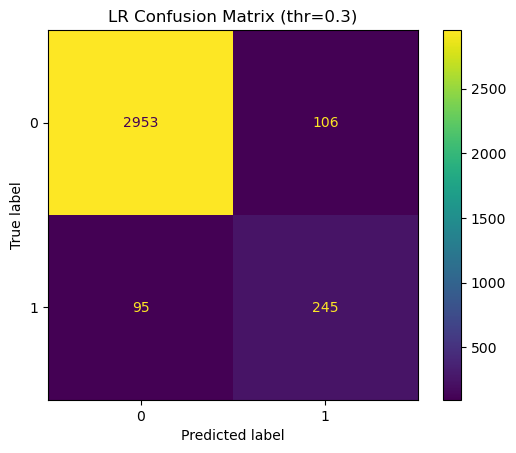


------------------------------------------------------------
Logistic Regression @ threshold=0.4
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      3059
           1       0.77      0.68      0.72       340

    accuracy                           0.95      3399
   macro avg       0.87      0.83      0.85      3399
weighted avg       0.95      0.95      0.95      3399



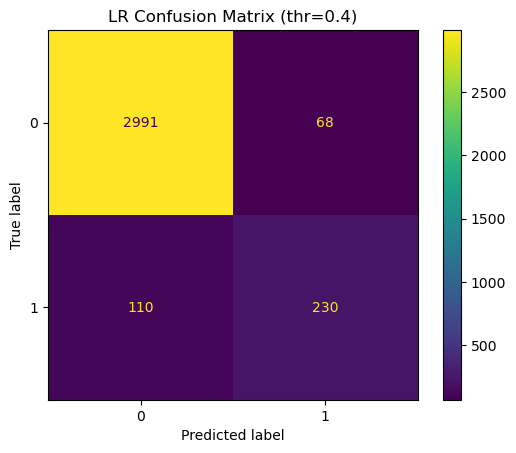


------------------------------------------------------------
Logistic Regression @ threshold=0.5
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      3059
           1       0.83      0.64      0.72       340

    accuracy                           0.95      3399
   macro avg       0.90      0.81      0.85      3399
weighted avg       0.95      0.95      0.95      3399



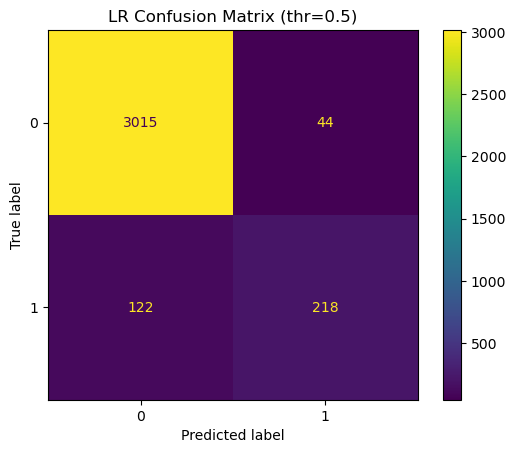

In [8]:
def evaluate_at_threshold(y_true, probs, thr: float):
    y_pred = (probs >= thr).astype(int)
    return {
        "threshold": thr,
        "precision": ( (y_pred[y_pred==1] == y_true[y_pred==1]).mean() if (y_pred==1).any() else 0.0 ),
        "recall": ( (y_pred[y_true==1] == 1).mean() if (y_true==1).any() else 0.0 ),
        "report": classification_report(y_true, y_pred, zero_division=0, output_dict=False),
        "cm": confusion_matrix(y_true, y_pred, labels=[0,1])
    }

for thr in [0.20, 0.30, 0.40, 0.50]:
    out = evaluate_at_threshold(y_test.values, lr_probs, thr)
    print("\n" + "-"*60)
    print(f"Logistic Regression @ threshold={thr}")
    print(out["report"])
    disp = ConfusionMatrixDisplay(out["cm"], display_labels=[0,1])
    disp.plot()
    plt.title(f"LR Confusion Matrix (thr={thr})")
    plt.show()

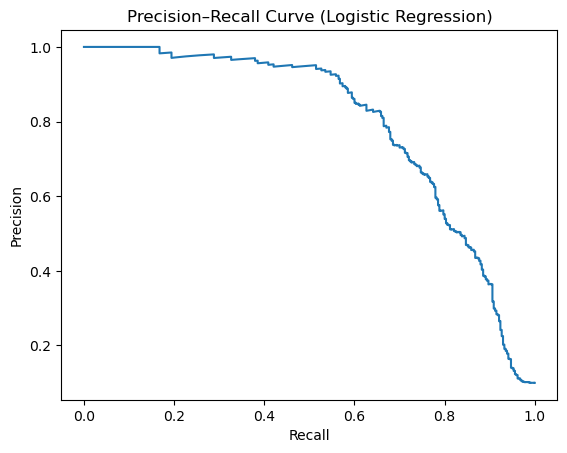

In [9]:
precision, recall, thresholds = precision_recall_curve(y_test, lr_probs)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Logistic Regression)")
plt.show()

### Threshold Selection

- 0.2 high sensitivity (recall = 78%) but lower precision (61%).
- 0.3 performance is more balanced (precision = 70%, recall = 72%).
- 0.5 precision increases to 83%, but recall drops to 64%. https://pmc.ncbi.nlm.nih.gov/articles/PMC4194673

A threshold of 0.30 provides a balanced trade-off between sensitivity and precision.

*According to clinical prediction model evaluation literature, a fixed probability threshold (e.g., 0.5) is not inherently optimal. Instead, thresholds should be chosen based on the clinical and operational consequences of false positives and false negatives (Ash et al., *Health Care Financ Rev*, 2000).*

## Gradient model

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier( 
    n_estimators=300, 
    learning_rate=0.05, 
    max_depth=3, 
    random_state=42)

gb.fit(X_train[numeric_cols], y_train)

gb_probs = gb.predict_proba(X_test[numeric_cols])[:, 1]

roc_gb = roc_auc_score(y_test, gb_probs) 
pr_gb = average_precision_score(y_test, gb_probs) 
print({"gb_roc_auc": roc_gb, "gb_pr_auc": pr_gb})

{'gb_roc_auc': 0.9999711555102591, 'gb_pr_auc': 0.9997467377404484}


In [11]:
patient_model_df[["total_cost", "avg_cost_per_visit", "n_visits", "total_los_days"]].corr()

,total_cost,avg_cost_per_visit,n_visits,total_los_days
total_cost,1.00,0.79,0.30,0.43
avg_cost_per_visit,0.79,1.00,0.01,0.19
n_visits,0.30,0.01,1.00,0.64
total_los_days,0.43,0.19,0.64,1.00


**Note:** Model achieves near-perfect discrimination due to strong correlation between utilization intensity features and the high-cost label. We should focus for now on logistic regression as the primary model for interpretability and robustness.

## Odds Ratios

In [12]:
log_reg = lr_model.named_steps["clf"]
encoder = lr_model.named_steps["prep"].named_transformers_["cat"]

feature_names_cat = encoder.get_feature_names_out(categorical_cols)
feature_names = np.concatenate([feature_names_cat, np.array(numeric_cols)])

coefs = log_reg.coef_[0]
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "odds_ratio": np.exp(coefs)
}).sort_values("odds_ratio", ascending=False)

coef_df.head(10)

,feature,coefficient,odds_ratio
2549,total_los_days,0.33,1.39
2525,dominant_specialty_Physical Medicine & Rehabil...,0.01,1.01
2474,dominant_specialty_Critical Care Medicine,0.00,1.00
1382,costliest_dx_Multiple myeloma not having achie...,0.00,1.00
2487,dominant_specialty_Hematology & Oncology,0.00,1.00
950,costliest_dx_Hemiplegia and hemiparesis follow...,0.00,1.00
2497,dominant_specialty_Medical Oncology,0.00,1.00
1464,costliest_dx_Nontraumatic intracerebral hemorr...,0.00,1.00
2427,costliest_dx_Ventricular fibrillation,0.00,1.00
315,costliest_dx_Bloodstream infection due to cent...,0.00,1.00


In [13]:
coef_df.sort_values("odds_ratio", ascending=True).head(10)

,feature,coefficient,odds_ratio
2547,n_visits,-1.94,0.14
2550,avg_los_days,-0.60,0.55
2506,dominant_specialty_Obstetrics & Gynecology,-0.39,0.68
2492,dominant_specialty_Hospitalist,-0.19,0.83
2478,dominant_specialty_Emergency Medicine,-0.18,0.84
2503,dominant_specialty_No Specialty,-0.13,0.88
2542,dominant_specialty_Surgery,-0.12,0.89
2494,dominant_specialty_Internal Medicine,-0.12,0.89
2510,dominant_specialty_Orthopaedic Surgery,-0.07,0.93
2093,"costliest_dx_Sepsis, unspecified organism",-0.06,0.94


**Note:** Interpretation of logistic regression coefficients should be understood as associations, not causal effects. 

The model is largely identifying patients who already show high utilization patterns, rather than uncovering separate causal risk factors. Consider asking for more demographic data (age, comorbilities, social determinants (SDOH), baseline clinical severity)

## Readmissions

In [14]:
dx_diversity = (
    gt_ip.groupby("deid_personid")["icddescription"]
    .nunique()
    .reset_index(name="n_unique_dx")
)

spec_diversity = (
    gt_ip.groupby("deid_personid")["servicing_specialty"]
    .nunique()
    .reset_index(name="n_unique_specialties")
)

patient_model_df = (
    patient_model_df
    .merge(dx_diversity, on="deid_personid", how="left")
    .merge(spec_diversity, on="deid_personid", how="left")
)

patient_model_df[["n_unique_dx", "n_unique_specialties"]].describe()

,n_unique_dx,n_unique_specialties
count,"16,991.00","16,991.00"
mean,1.34,1.28
std,0.80,0.67
min,1.00,1.00
25%,1.00,1.00
50%,1.00,1.00
75%,1.00,1.00
max,10.00,8.00


In [15]:
y_r = patient_model_df["any_readmit_30"]

X_r = patient_model_df[
    [
        "n_visits",
        "total_los_days",
        "avg_los_days",
        "n_unique_dx",
        "n_unique_specialties",
        "costliest_dx",
        "dominant_specialty",
    ]
].copy()

X_r["costliest_dx"] = X_r["costliest_dx"].fillna("UNKNOWN")
X_r["dominant_specialty"] = X_r["dominant_specialty"].fillna("UNKNOWN")

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_r, y_r,
    test_size=0.2,
    random_state=42,
    stratify=y_r
)

preprocess_r = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["costliest_dx", "dominant_specialty"]),
        ("num", "passthrough", ["n_visits", "total_los_days", "avg_los_days", "n_unique_dx", "n_unique_specialties"])
    ]
)

lr_readmit = Pipeline([
    ("prep", preprocess_r),
    ("clf", LogisticRegression(max_iter=2000))
])

lr_readmit.fit(Xr_train, yr_train)
probs_r = lr_readmit.predict_proba(Xr_test)[:, 1]

print({
    "readmit_roc_auc": roc_auc_score(yr_test, probs_r),
    "readmit_pr_auc": average_precision_score(yr_test, probs_r),
    "base_rate": yr_test.mean()
})

{'readmit_roc_auc': 0.9518552132493772, 'readmit_pr_auc': 0.640396685881183, 'base_rate': 0.07472786113562813}


The 30-day readmission model demonstrates strong discriminatory performance (ROC-AUC = 0.95, PR-AUC = 0.64). 

Given a base readmission rate of 7.5%, the model substantially improves identification of high-risk patients. Predictors reflecting clinical complexity (utilization intensity, diagnostic diversity, and specialty diversity) contribute meaningfully to discrimination.


## Key Findings

1. High-cost concentration is strongly associated with utilization intensity.  
   Length of stay and cost per visit were the strongest structural correlates of high-cost classification.

2. Logistic regression demonstrated strong discriminatory performance for identifying top-decile cost patients (ROC-AUC ≈ 0.92, PR-AUC ≈ 0.79).  
   Threshold selection meaningfully altered the precision–recall trade-off (0.30).

3. High-cost prediction is largely driven by patterns of resource use rather than independent causal risk factors.

4. The 30-day readmission model achieved strong performance (ROC-AUC ≈ 0.95, PR-AUC ≈ 0.64) despite having a low base rate (~7.5%).

## Future research

1. Consider baseline clinical severity, comorbidity, and social determinants of health (SDOH) to evaluate non-clinical drivers of cost and readmission.

2. Evaluate temporal modeling approaches to ensure predictors precede the outcome event, particularly for readmission.

## Readmission rates


In [16]:
pd.crosstab(
    patient_model_df["high_cost_p90"],
    patient_model_df["n_visits"] > 1,
    normalize="index"
)

n_visits,False,True
high_cost_p90,,
0,0.80,0.20
1,0.42,0.58


In [17]:
pd.crosstab(
    patient_model_df["high_cost_p90"],
    patient_model_df["n_readmit_30"] > 1,
    normalize="index"
)

n_readmit_30,False,True
high_cost_p90,,
0,0.99,0.01
1,0.90,0.10


In [18]:
pd.crosstab(
    patient_model_df["n_readmit_30"] > 1,
    patient_model_df["high_cost_p90"],
    normalize="index"
)

high_cost_p90,0,1
n_readmit_30,,
False,0.91,0.09
True,0.48,0.52
